# Day 17 Revision Summary — k-means Clustering

- **Unsupervised learning is new today.** Every model before this got features *and* labels (X → y). Clustering only gets X — no y — and has to find natural groups in the data by itself.
- **k-means = assign → move → repeat.** Drop `k` random centre points, assign every data point to its nearest centre, slide each centre to the average (mean) of the points assigned to it, and repeat until the centres stop moving.
- **Inertia is the score k-means minimises**: the sum of squared distances from every point to its own cluster centre. Small = tight, snug groups. But more clusters *always* lowers inertia (k = every point its own cluster → inertia 0), so you can never pick k by minimising inertia alone.
- **Always scale before k-means.** It measures distance, just like KNN and logistic regression — an unscaled feature with big numbers (e.g. income) would dominate every distance calculation. Run `StandardScaler` first.
- **Choosing k takes two tools, not one formula**: the *elbow method* (plot inertia vs k, look for where the drop flattens) and the *silhouette score* (average how snugly each point sits in its group, from −1 to +1, highest wins). On iris they disagree — silhouette prefers k=2, the elbow prefers k=3 — and that's fine: when the tools disagree, you decide using judgement about the problem, there's no single right answer.

In [15]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

# ... then your imports/code below
from sklearn.cluster import KMeans

## Classwork Exercise 1 — Cluster the flowers (`kmeans_basic.py`, ~15 min)

**What's being asked:** Load the iris dataset (features only, no labels), scale it, fit a `KMeans(n_clusters=3, n_init=10, random_state=42)`, then check whether the 3 clusters it found on its own line up with the 3 real species.

**Approach:**
1. Load `load_iris(as_frame=True)` — keep `.data` as `X` and `.target` as `species` (species is only for checking afterwards, never used for training).
2. Scale `X` with `StandardScaler` — k-means measures distance, so this step is not optional.
3. Fit `KMeans(n_clusters=3, n_init=10, random_state=42)` and call `fit_predict` to get a cluster label (0/1/2) per row.
4. Print `km.inertia_` and the size of each cluster.
5. Build a `pd.crosstab(labels, species)` to see which species came out cleanest (expect one cluster to match one species almost exactly).
6. **Stretch:** repeat once without scaling — do the clusters get worse? By how much does inertia change?

In [16]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# TODO 1: Load the iris data. Keep the features as X and the true labels as
# `species` (species is ONLY for checking your clusters afterwards).
X = load_iris(as_frame=True).data
species = load_iris().target

# TODO 2: Scale the features with StandardScaler before clustering.
X_sel = StandardScaler().fit_transform(X)


# TODO 3: Fit KMeans(n_clusters=3, n_init=10, random_state=42) and get labels
km = KMeans(n_clusters=3 , n_init=10 , random_state=42)
labels = km.fit_predict(X_sel)


# TODO 4: Print km.inertia_ and the cluster sizes (hint: pd.Series(labels).value_counts()).
print(km.inertia_)
print(pd.Series(labels).value_counts().sort_index().to_string())

# TODO 5: Cross-tab clusters vs true species with pd.crosstab(labels, species).
print(pd.crosstab(labels , species))

# TODO 6 (stretch): repeat once WITHOUT scaling. Do the clusters get worse?
# How much does inertia change?


139.82049635974974
0    53
1    50
2    47
col_0   0   1   2
row_0            
0       0  39  14
1      50   0   0
2       0  11  36


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Classwork Exercise 2 — The elbow method (`elbow.py`, ~10 min)

**What's being asked:** k-means can't tell you how many groups exist — you have to guess `k` and check. The elbow trick: fit k-means for a range of `k` values, plot how much inertia drops each time, and look for the point where the drops suddenly get small (the "elbow" of the arm).

**Approach:**
1. Load and scale iris the same way as Exercise 1.
2. Loop `k` from 1 to 10. For each `k`, fit `KMeans(n_clusters=k, n_init=10, random_state=42)` and record `km.inertia_`.
3. Print each `k` next to its inertia and the drop from the previous `k`.
4. Find where the drop shrinks a lot — that's your elbow (expect it around k=3 for iris).

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[599.9999999999999, 222.36170496502297, 139.82049635974974, 114.09254690403084, 90.92751382392046, 81.54439095511778, 72.63114382667186, 62.54060569578121, 55.11949280529059, 47.39103517634708]


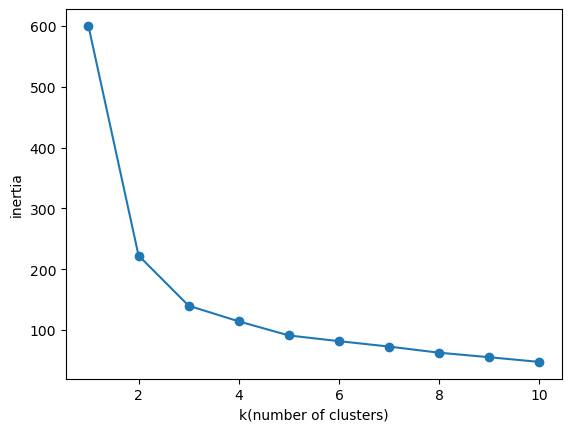

In [17]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# TODO 1: Load iris features and scale them (same as Exercise 1).
X = load_iris(as_frame=True).data
X_scaled = StandardScaler().fit_transform(X)


# TODO 2: Loop k = 1..10. For each k:
ks = []
inertias = []
for k in range(1, 11):
    km = KMeans(k , n_init=10 , random_state=42)
    km.fit(X_scaled)
    inertia = km.inertia_
    ks.append(k)
    inertias.append(inertia)
print(ks)
print(inertias)

# TODO 3 (stretch): plot inertia vs k with matplotlib (plt.plot(ks, inertias))
import matplotlib.pyplot as plt
plt.plot(ks,inertias , marker = 'o')
plt.xlabel("k(number of clusters)")
plt.ylabel("inertia")
plt.show()




## Classwork Exercise 3 — The silhouette score (`silhouette.py`, ~10 min)

**What's being asked:** A second opinion on `k`. The silhouette score rates every point from −1 to +1 (+1 = snug in its cluster, 0 = on the border, −1 = probably in the wrong cluster) and averages it over all points. The `k` with the highest average silhouette wins.

**Approach:**
1. Load and scale iris the same way as Exercise 1.
2. Loop `k` from 2 to 6 (silhouette needs at least 2 clusters).
3. For each `k`, fit `KMeans(n_clusters=k, n_init=10, random_state=42)`, get the labels, and compute `silhouette_score(X_scaled, labels)`.
4. Print each `k` next to its score and note which `k` scores highest.
5. Write one sentence: given that the elbow liked k=3 and silhouette might like a different k, which `k` would you actually pick for iris, and why?

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# TODO 1: Load iris features and scale them (same as Exercise 1).
X = load_iris(as_frame=True).data
X_scaled = StandardScaler().fit_transform(X)


print("k silhouette")
for k in range(2, 7):
    km = KMeans(k , n_init= 10 , random_state=42)
    km.fit(X_scaled)
    
    

# TODO 2: In a markdown cell or comment, write one sentence on which k you'd
# pick for iris and why.


## Homework 1 — Cluster the wine dataset

**What's being asked:** Apply the same workflow (scale → elbow → silhouette) to a new, unfamiliar dataset: `load_wine` (13 features, no labels used for training). Decide how many natural groups it has.

**Approach:**
1. Load `load_wine(as_frame=True)`, keep `.data` as `X` (and `.target` only for checking afterwards, if you want).
2. Scale `X` with `StandardScaler`.
3. Run the elbow loop (`k` = 1..10) and note where the drop flattens.
4. Run the silhouette loop (`k` = 2..6) and note which `k` scores highest.
5. Write a sentence on how many groups you'd pick for wine, and whether it matches the 3 real wine classes.

In [ ]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# TODO 1: Load load_wine and scale the features.
# X = ...
# X_scaled = ...

# TODO 2: Elbow — loop k = 1..10, print inertia and the drop from the
# previous k.

# TODO 3: Silhouette — loop k = 2..6, print the silhouette score for each.

# TODO 4: In a comment, note how many groups you'd pick for wine and why.


## Homework 2 — Repeat iris without scaling

**What's being asked:** Re-run the Exercise 1 clustering on iris, but skip the `StandardScaler` step, and compare the result to the scaled version. This is meant to make the "always scale before k-means" rule concrete.

**Approach:**
1. Load iris features (`X`) and the true species labels, same as Exercise 1.
2. Fit `KMeans(n_clusters=3, n_init=10, random_state=42)` directly on the **unscaled** `X`.
3. Print the inertia and cross-tab clusters vs true species.
4. Compare against your scaled result from Exercise 1: did inertia change a lot? Did the clusters get messier or cleaner? Write one sentence explaining why, in terms of which feature has the largest raw scale.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

# TODO 1: Load iris features (X) and true species labels, WITHOUT scaling X.
# X = ...
# species = ...

# TODO 2: Fit KMeans(n_clusters=3, n_init=10, random_state=42) directly on
# the unscaled X.
# km = ...
# labels = ...

# TODO 3: Print km.inertia_ and pd.crosstab(labels, species).

# TODO 4: In a comment, compare this to the scaled result from Exercise 1 —
# what changed, and why?


## Other homework items (no code needed)

- Read `formulas.md` in today's Drive folder for the first-principles derivations of inertia, distance, and the silhouette score.
- Commit your work: `git add . && git commit -m "day 17"`.